In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Memuat dataset orders
orders = pd.read_csv('data/olist_orders_dataset.csv')

# 2. Mengubah tipe data semua kolom waktu menjadi format Datetime
date_columns = [
    'order_purchase_timestamp', 
    'order_approved_at',
    'order_delivered_carrier_date', 
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

print("✅ Data berhasil dimuat dan format tanggal sudah disesuaikan!")
print("-" * 50)
# Menampilkan info data untuk memastikan tipe datanya sudah 'datetime64'
print(orders[date_columns].info())

✅ Data berhasil dimuat dan format tanggal sudah disesuaikan!
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_purchase_timestamp       99441 non-null  datetime64[ns]
 1   order_approved_at              99281 non-null  datetime64[ns]
 2   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 3   order_delivered_customer_date  96476 non-null  datetime64[ns]
 4   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5)
memory usage: 3.8 MB
None


In [2]:
# 1. Filter hanya pesanan yang sudah berstatus 'delivered' (terkirim)
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()

# Hapus baris yang tanggal pengiriman aktualnya kosong (missing values)
delivered_orders.dropna(subset=['order_delivered_customer_date', 'order_estimated_delivery_date'], inplace=True)

# 2. Menghitung selisih hari (Aktual Tiba - Estimasi Tiba)
# Hasil positif (+) = Terlambat
# Hasil negatif (-) = Datang lebih cepat dari estimasi
delivered_orders['delay_days'] = (delivered_orders['order_delivered_customer_date'] - delivered_orders['order_estimated_delivery_date']).dt.days

# 3. Membuat kolom kategori status pengiriman
def categorize_delivery(days):
    if days > 0:
        return 'Delayed (Terlambat)'
    else:
        return 'On-Time (Tepat Waktu)'

delivered_orders['delivery_status'] = delivered_orders['delay_days'].apply(categorize_delivery)

# 4. Menampilkan hasil perhitungan jumlah paket terlambat vs tepat waktu
status_counts = delivered_orders['delivery_status'].value_counts()
status_percentage = delivered_orders['delivery_status'].value_counts(normalize=True) * 100

print("Ringkasan Status Pengiriman Olist E-Commerce:")
print("-" * 45)
for status in status_counts.index:
    print(f"{status}: {status_counts[status]:,} pesanan ({status_percentage[status]:.1f}%)")

Ringkasan Status Pengiriman Olist E-Commerce:
---------------------------------------------
On-Time (Tepat Waktu): 89,936 pesanan (93.2%)
Delayed (Terlambat): 6,534 pesanan (6.8%)


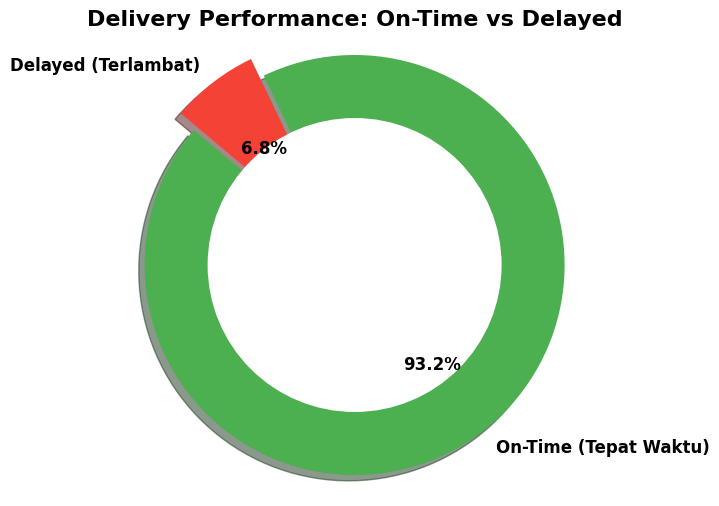

In [3]:
# 1. Membuat visualisasi Donut Chart untuk Status Pengiriman
plt.figure(figsize=(8, 6))

# Menyiapkan data dan warna (Hijau untuk On-Time, Merah untuk Delayed)
labels = status_counts.index
sizes = status_counts.values
colors = ['#4CAF50', '#F44336'] 
explode = (0, 0.1)  # Efek 'meledak' (terpisah) untuk bagian yang terlambat

# Membuat Pie Chart dasar
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140, textprops={'fontsize': 12, 'fontweight': 'bold'})

# Menambahkan lingkaran putih di tengah agar berubah menjadi Donut Chart
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Estetika grafik
plt.title('Delivery Performance: On-Time vs Delayed', fontsize=16, fontweight='bold')
plt.axis('equal') # Memastikan bentuknya lingkaran sempurna

# Menyimpan grafik sebagai gambar untuk GitHub nanti
plt.savefig('delivery_status_chart.png', dpi=300, bbox_inches='tight')

plt.show()

In [4]:
# Mengambil hanya data pesanan yang terlambat
delayed_orders = delivered_orders[delivered_orders['delay_days'] > 0]

# Menghitung statistik keterlambatan
rata_rata_telat = delayed_orders['delay_days'].mean()
median_telat = delayed_orders['delay_days'].median()
maksimal_telat = delayed_orders['delay_days'].max()

print("Statistik Keterlambatan Pengiriman:")
print("-" * 35)
print(f"Rata-rata keterlambatan: {rata_rata_telat:.1f} hari")
print(f"Nilai tengah (Median)  : {median_telat:.0f} hari")
print(f"Keterlambatan terparah : {maksimal_telat:.0f} hari")

Statistik Keterlambatan Pengiriman:
-----------------------------------
Rata-rata keterlambatan: 10.6 hari
Nilai tengah (Median)  : 7 hari
Keterlambatan terparah : 188 hari
